# Miguel Baños Baladrón
# Pablo Díaz Blanco
### Grupo de prácticas 1.1
### Principios de Visión por Computador

# Ejercicio 2.- Reconocimiento de objetos

# Importaciones

In [13]:
import os
import numpy as np
from skimage import io
import matplotlib.pyplot as plt

In [2]:
k = 500

# Carga y Preparación de datos

In [3]:
BASE_PATH = "objects"
IMAGES_PATH = os.path.join(BASE_PATH, "images")
MASKS_PATH  = os.path.join(BASE_PATH, "masks")

CLASSES = ["elephant", "emu", "flamingo", "rhino"]

images = []
masks  = []
labels = []
label_ids = []

for idx, cls in enumerate(CLASSES): # Para cada índice y cada clase
    img_dir  = os.path.join(IMAGES_PATH, cls)
    mask_dir = os.path.join(MASKS_PATH, cls)

    # Ordenamos para hacer coincidir imagen con máscara
    img_files  = sorted(os.listdir(img_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_file, mask_file in zip(img_files, mask_files): # Para cada pareja imagen-máscara
        img_path  = os.path.join(img_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        img  = io.imread(img_path)
        mask = io.imread(mask_path)

        images.append(img)
        masks.append(mask)
        labels.append(cls)
        label_ids.append(idx)

images = np.array(images, dtype=object)
masks  = np.array(masks, dtype=object)
label_ids = np.array(label_ids)

print("Datos cargados correctamente")
print("Nº imágenes:", len(images))
print("Nº máscaras:", len(masks))
print("Ejemplo etiqueta:", labels[21])
print("ID de etiqueta:", label_ids[0])

Datos cargados correctamente
Nº imágenes: 243
Nº máscaras: 243
Ejemplo etiqueta: elephant
ID de etiqueta: 0


# Preprocesado

In [ ]:
# Normalización

# ¿Augmentation?
# Codificar etiquetas ¿3 o 4 clases?
# Dividir en entrenamiento/validación/test

- ## Función apply_mask() 
### En este problema de clasificación, las features de entrada del modelo van a ser características de las imágenes, no de los píxeles (como en el anterior). Sin embargo, no usaremos ni las imágenes a color de los animales ni sus máscaras, sino que usaremos imágenes generadas tras aplicar la máscara a las imágenes de los animales, con la función apply_mask(). Con esto, mejoramos la calidad de las features, ya que evitamos que se introduzca el ruido del fondo de las imágenes (vegetación, cielo,...).

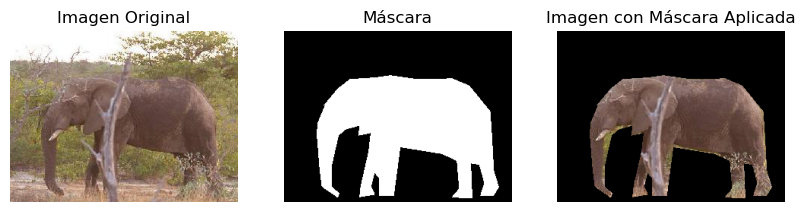

In [14]:
def apply_mask(image, mask):
    mask_norm = mask > 0  # Convertir la máscara a valores binarios (True o False)

    if len(image.shape) == 3 and len(mask.shape) == 2:
        # Expandir la máscara para que tenga la forma (h, w, 1) antes de la multiplicación
        mask_norm = mask_norm[..., None]  
    
    mask_applied = image * mask_norm

    # Mostrar las imágenes: Original, Máscara y Resultado (con la máscara aplicada)
    plt.figure(figsize=(10, 5))

    # Imagen original
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Imagen Original")
    plt.axis('off')

    # Máscara
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Máscara")
    plt.axis('off')

    # Imagen tras aplicar la máscara
    plt.subplot(1, 3, 3)
    plt.imshow(mask_applied)
    plt.title("Imagen con Máscara Aplicada")
    plt.axis('off')

    plt.show()

    return mask_applied

# Seleccionar la primera imagen y su máscara
first_image = images[0]
first_mask = masks[0]

# Aplicar la máscara a la imagen
first_image_masked = apply_mask(first_image, first_mask)

- ## Función select_k_pixels()
- ### Con esta función seleccionamos k píxeles de las imágenes tras aplicarles la máscara. El objetivo es reducir la dimensionalidad de los datos, utilizando solo una parte representativa de la imagen en lugar de todos sus píxeles. Esto ayuda a mantener la consistencia en el tamaño de entrada para el modelo  lo que mejora la eficiencia y el rendimiento del clasificador.

In [ ]:
def select_k_pixels(image, k):
    image_flattened = image.flatten()
    selected_pixels = image_flattened[:k]  # Selecciona los primeros k píxeles
    return selected_pixels

- ## Normalización